# Figure5_1

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure5")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM
from functions.utils import index_in, first_trials_by_image
from functions.decoding import load_feature_mat, image_basenames, pca_standardize, fit_logistic
from functions.plotting import set_paper_theme

set_paper_theme()


In [ ]:

def load_behavior_data(task):
    trials_main,trials_gen = [],[]
    for monkey in ["Elsa","Judy","Olaf"]:
        _trials,_ = loadTrialsM(task,monkey)
        # exclude the swipe-format anchor-image practice session
        _trials_main = [trial for trial in _trials if trial["trial_type"]=="main"]
        _trials_gen,_ = first_trials_by_image([trial for trial in _trials if trial["trial_type"]=="gen"])
        trials_main.extend(_trials_main)
        trials_gen.extend(_trials_gen)

    gen_acc = np.mean([trial["result"]=="CORRECT" for trial in trials_gen])

    images_main = np.array([trial["img_url"].split("/")[-1] for trial in trials_main])
    images_gen = np.array([trial["img_url"].split("/")[-1] for trial in trials_gen])

    _choices_main = np.array([trial["targ_cat"][trial["response"]-1] for trial in trials_main])
    _choices_gen = np.array([trial["targ_cat"][trial["response"]-1] for trial in trials_gen])
    _category_main = np.array([trial["targ_cat"][trial["targ_cor"]-1] for trial in trials_main])
    _category_gen = np.array([trial["targ_cat"][trial["targ_cor"]-1] for trial in trials_gen])

    target2 = np.sort(list(set(_choices_main)))[1]
    choices_main = (_choices_main == target2) + 1
    category_main = (_category_main == target2) + 1
    choices_gen = (_choices_gen == target2) + 1
    category_gen = (_category_gen == target2) + 1
    return gen_acc,images_main,choices_main,category_main,images_gen,choices_gen,category_gen


def load_model_feature(feature_name,model_name,images_main,images_gen):
    X,_,fnames = load_feature_mat(f"data_model/largetask_features/{feature_name}_{model_name}.mat")
    trial_type = np.array([name.split("\\")[2] for name in fnames])
    names = image_basenames(fnames)

    names_main = names[trial_type=="anchor"]
    names_gen = names[trial_type=="stim"]
    X_main = X[trial_type=="anchor"]
    X_gen = X[trial_type=="stim"]

    # features above 20 dims are PCA-reduced to 20 and z-scored with the
    # anchor statistics; the shipped (already PCA-reduced) features are used as-is
    if X_main.shape[1] > 20:
        X_main,X_gen = pca_standardize(X_main,X_gen)

    XX_main = X_main[index_in(images_main,names_main)]
    XX_gen = X_gen[index_in(images_gen,names_gen)]
    return XX_main,XX_gen


def run_classification_and_fit(XX_main,choices_main,category_main,XX_gen,choices_gen,category_gen):
    # decode the true category of each gen image
    pred = fit_logistic(XX_main, category_main).predict(XX_gen)
    classification_correct = pred == category_gen
    Pcorrect = np.mean(classification_correct)
    Pcorrect_SE = np.sqrt(Pcorrect*(1-Pcorrect)/len(category_gen))
    # fit the monkeys' choices on the same features
    pred = fit_logistic(XX_main, choices_main).predict(XX_gen)
    matched = pred == choices_gen
    Pmatch = np.mean(matched)
    Pmatch_SE = np.sqrt(Pmatch*(1-Pmatch)/len(category_gen))
    return Pcorrect,Pcorrect_SE,Pmatch,Pmatch_SE,classification_correct,matched


## Panels A–B — Shared model evaluation

In [4]:

models = ["v1_like","LUV","gistSF","texture","alexnet","vgg16","resnet50",
          "vit_b_32","dino_vitb","clip","siglip2"]

task_names = ["Large_animate_vs_inanimate","Large_mammal_vs_nonmammal","Large_natural_vs_artificial"]
feature_names = ["Large_animate_vs_inanimate","Large_mammal_vs_nonmammal","Large_natural_vs_artificial"]
colors = ["black","#5EA66B","#8074B1"]


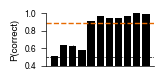

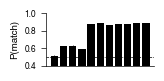

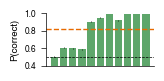

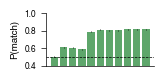

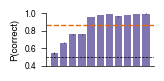

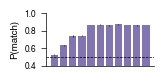

In [5]:

prediction_tables = []

for i in range(3):
    task_name = task_names[i]
    feature_name = feature_names[i]
    save_path_generalization = FIGURE_OUTPUT_DIR / f"model_classification_{feature_name}.pdf"
    save_path_behaviorfitting = FIGURE_OUTPUT_DIR / f"model_choice_fit_{feature_name}.pdf"

    (gen_acc, images_main, choices_main, category_main,
     images_gen, choices_gen, category_gen) = load_behavior_data(task_name)
    monkey_performance = gen_acc

    Pmatch,Pmatch_SE = [],[]
    Pcorrect,Pcorrect_SE = [],[]
    for model_name in models:
        XX_main,XX_gen = load_model_feature(feature_name,model_name,images_main,images_gen)
        pcorrect,pcorrect_se,pmatch,pmatch_se,correct,matched = run_classification_and_fit(
            XX_main,choices_main,category_main,XX_gen,choices_gen,category_gen)

        prediction_tables.append(pd.DataFrame({
            "task": task_name, "model": model_name, "method": "Linear",
            "trial_index": np.arange(len(images_gen)), "image": images_gen,
            "classification_correct": correct.astype(int),
            "choice_matched": matched.astype(int),
            "monkey_correct": (choices_gen == category_gen).astype(int),
        }))

        Pmatch.append(pmatch)
        Pmatch_SE.append(pmatch_se)
        Pcorrect.append(pcorrect)
        Pcorrect_SE.append(pcorrect_se)

    f, ax = plt.subplots()
    f.set(figwidth=110/72,figheight=50/72)
    ax.bar(range(len(models)),Pcorrect,yerr=Pcorrect_SE,error_kw={'elinewidth':0.5},color=colors[i])
    ax.set_yticks([0.4,0.6,0.8,1])
    ax.set_ylim([0.4,1])
    ax.set_xticks([])
    ax.axhline(0.5,color="black",linestyle="dashed",linewidth=0.5)
    ax.axhline(monkey_performance,color="#E76A00",linestyle="dashed",linewidth=1)
    ax.set_ylabel("P(correct)")
    plt.savefig(save_path_generalization)
    plt.show()

    f, ax = plt.subplots()
    f.set(figwidth=110/72,figheight=50/72)
    ax.bar(range(len(models)),Pmatch,yerr=Pmatch_SE,error_kw={'elinewidth':0.5},color=colors[i])
    ax.set_yticks([0.4,0.6,0.8,1])
    ax.set_ylim([0.4,1])
    ax.set_xticks([])
    ax.axhline(0.5,color="black",linestyle="dashed",linewidth=0.5)
    ax.set_ylabel("P(match)")
    plt.savefig(save_path_behaviorfitting)
    plt.show()

pd.concat(prediction_tables, ignore_index=True).to_csv(
    FIGURE_OUTPUT_DIR / "model_trial_predictions.csv", index=False)
